In [1]:
import findspark
findspark.init()

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder. \
    appName("pyspark-1"). \
    getOrCreate()

In [3]:
import pyspark.sql.functions as  F
from pyspark.sql.window import Window
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, TimestampType, DoubleType, DateType
import matplotlib.pyplot as plt


### Read data

In [4]:
schema=StructType([StructField('Job ID',IntegerType(),True),\
                  StructField('Agency',StringType(),True),\
                  StructField('Posting Type',StringType(),True),\
                  StructField('# Of Positions',IntegerType(),True),\
                  StructField('Business Title',StringType(),True),\
                  StructField('Civil Service Title',StringType(),True),\
                  StructField('Title Code No',StringType(),True),\
                  StructField('Level',StringType(),True),\
                  StructField('Job Category',StringType(),True),\
                  StructField('Full-Time/Part-Time indicator',StringType(),True),\
                  StructField('Salary Range From',DoubleType(),True),\
                  StructField('Salary Range To',DoubleType(),True),\
                  StructField('Salary Frequency',StringType(),True),\
                  StructField('Work Location',StringType(),True),\
                  StructField('Division/Work Unit',StringType(),True),\
                  StructField('Job Description',StringType(),True),\
                  StructField('Minimum Qual Requirements',StringType(),True),\
                  StructField('Preferred Skills',StringType(),True),\
                  StructField('Additional Information',StringType(),True),\
                  StructField('To Apply',StringType(),True),\
                  StructField('Hours/Shift',StringType(),True),\
                  StructField('Work Location 1',StringType(),True),\
                  StructField('Recruitment Contact',StringType(),True),\
                  StructField('Residency Requirement',StringType(),True),\
                  StructField('Posting Date',TimestampType(),True),\
                  StructField('Post Until',TimestampType(),True),\
                  StructField('Posting Updated',TimestampType(),True),\
                  StructField('Process Date',TimestampType(),True)  ]               
                 )

In [5]:
df = spark.read.csv("/dataset/nyc-jobs.csv", header=True, schema=schema, multiLine=True,escape='"',quote='"',mode="PERMISSIVE")
df.printSchema()

root
 |-- Job ID: integer (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: integer (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: double (nullable = true)
 |-- Salary Range To: double (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirements: string (nullable = true)
 |-- Preferred Skills: string (nullable = true)
 |-- Additional Information: string (nullable = true)
 |-- To Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable = true)
 |-- Work Locat

# Data Exploration


#Detailed analysis of source data:

In [6]:
print("Sample data : ")
df.show(5)

Sample data : 
+------+--------------------+------------+--------------+--------------------+--------------------+-------------+-----+--------------------+-----------------------------+-----------------+---------------+----------------+--------------------+--------------------+--------------------+-------------------------+--------------------+----------------------+--------------------+-----------+---------------+-------------------+---------------------+-------------------+----------+-------------------+-------------------+
|Job ID|              Agency|Posting Type|# Of Positions|      Business Title| Civil Service Title|Title Code No|Level|        Job Category|Full-Time/Part-Time indicator|Salary Range From|Salary Range To|Salary Frequency|       Work Location|  Division/Work Unit|     Job Description|Minimum Qual Requirements|    Preferred Skills|Additional Information|            To Apply|Hours/Shift|Work Location 1|Recruitment Contact|Residency Requirement|       Posting Date|Pos

In [7]:
print("Total No of records : ", df.count())
print("\nTotal No of columns : ", len(df.columns))

print("\nColumns and Datatypes : ")
for i in df.schema.fields:
    print(i.name,"      ", i.dataType)
    
print("\nNullable Columns : ")
for i in df.schema.fields:
    if(i.nullable==True):
        print(i.name)

print("\nMandatory Columns : ")
for i in df.schema.fields:
    if(i.nullable==False):
        print(i.name)

Total No of records :  2946

Total No of columns :  28

Columns and Datatypes : 
Job ID        IntegerType
Agency        StringType
Posting Type        StringType
# Of Positions        IntegerType
Business Title        StringType
Civil Service Title        StringType
Title Code No        StringType
Level        StringType
Job Category        StringType
Full-Time/Part-Time indicator        StringType
Salary Range From        DoubleType
Salary Range To        DoubleType
Salary Frequency        StringType
Work Location        StringType
Division/Work Unit        StringType
Job Description        StringType
Minimum Qual Requirements        StringType
Preferred Skills        StringType
Additional Information        StringType
To Apply        StringType
Hours/Shift        StringType
Work Location 1        StringType
Recruitment Contact        StringType
Residency Requirement        StringType
Posting Date        TimestampType
Post Until        TimestampType
Posting Updated        TimestampTy

In [8]:
print("Null % for each column : ")
t=df.count()
for i in df.schema.fields:
    n=df.filter(F.col(i.name).isNull()).count()
    print(i.name, " : ", round((n/t)*100,2),"%")


Null % for each column : 
Job ID  :  0.0 %
Agency  :  0.0 %
Posting Type  :  0.0 %
# Of Positions  :  0.0 %
Business Title  :  0.0 %
Civil Service Title  :  0.0 %
Title Code No  :  0.0 %
Level  :  0.0 %
Job Category  :  0.07 %
Full-Time/Part-Time indicator  :  6.62 %
Salary Range From  :  0.0 %
Salary Range To  :  0.0 %
Salary Frequency  :  0.0 %
Work Location  :  0.0 %
Division/Work Unit  :  0.0 %
Job Description  :  0.0 %
Minimum Qual Requirements  :  0.68 %
Preferred Skills  :  13.34 %
Additional Information  :  37.07 %
To Apply  :  0.03 %
Hours/Shift  :  69.99 %
Work Location 1  :  53.9 %
Recruitment Contact  :  100.0 %
Residency Requirement  :  0.14 %
Posting Date  :  0.14 %
Post Until  :  70.43 %
Posting Updated  :  0.14 %
Process Date  :  0.14 %


In [9]:
print("Duplicates(at row level): ")
d=df.distinct().count()
t=df.count()
print("Distinct rows : ", d )
print("Total rows : ", t )
print("Duplicated rows : ", t-d)

print("\nDuplicates(at composite key['Job ID','Agency','Posting Type'] level): ")
a=df.distinct().groupBy('Job ID','Agency','Posting Type').count()
print("No of Duplicates : ", a.filter(F.col('count')>1).count())
a.filter(F.col('count')>1).show()

Duplicates(at row level): 
Distinct rows :  2912
Total rows :  2946
Duplicated rows :  34

Duplicates(at composite key['Job ID','Agency','Posting Type'] level): 
No of Duplicates :  1
+------+--------------------+------------+-----+
|Job ID|              Agency|Posting Type|count|
+------+--------------------+------------+-----+
|384143|CIVILIAN COMPLAIN...|    Internal|    2|
+------+--------------------+------------+-----+



In [10]:
num_cols = [] 
char_cols = []
date_cols = []
ctgr_cols = []

def categorical_cols(field,threshold=0.05): #Assuming if a column has upto 5 percent distinct values only then its categorial
    dist_c=df.filter(F.col(field).isNotNull()).select(F.approx_count_distinct(field).alias('d_val')).first()["d_val"]
    if((dist_c/t)<threshold):
        ctgr_cols.append(field) 

        
for field in df.schema.fields:
    if isinstance(field.dataType, (IntegerType, DoubleType)):
        num_cols.append(field.name)
        categorical_cols(field.name)
    elif isinstance(field.dataType, (DateType,TimestampType)):
        date_cols.append(field.name)
    else:
        char_cols.append(field.name)
        categorical_cols(field.name)


print("Total Numerical Columns", num_cols)
print("Total Character Columns:", char_cols)
print("Total Date Columns:", date_cols)
print("Total Categorical Columns:",ctgr_cols)

Total Numerical Columns ['Job ID', '# Of Positions', 'Salary Range From', 'Salary Range To']
Total Character Columns: ['Agency', 'Posting Type', 'Business Title', 'Civil Service Title', 'Title Code No', 'Level', 'Job Category', 'Full-Time/Part-Time indicator', 'Salary Frequency', 'Work Location', 'Division/Work Unit', 'Job Description', 'Minimum Qual Requirements', 'Preferred Skills', 'Additional Information', 'To Apply', 'Hours/Shift', 'Work Location 1', 'Recruitment Contact', 'Residency Requirement']
Total Date Columns: ['Posting Date', 'Post Until', 'Posting Updated', 'Process Date']
Total Categorical Columns: ['Agency', 'Posting Type', '# Of Positions', 'Level', 'Job Category', 'Full-Time/Part-Time indicator', 'Salary Frequency', 'Recruitment Contact', 'Residency Requirement']


In [11]:
print("Numerical column profiling : ")
for i in num_cols:
    df.select(F.min(i), F.max(i), F.round(F.avg(F.col(i)),2)).show()

print("\nDate Column Profiling : ")
for i in date_cols:
    df.select(F.min(i), F.max(i)).show()

Numerical column profiling : 
+-----------+-----------+---------------------+
|min(Job ID)|max(Job ID)|round(avg(Job ID), 2)|
+-----------+-----------+---------------------+
|      87990|     426238|            384821.56|
+-----------+-----------+---------------------+

+-------------------+-------------------+-----------------------------+
|min(# Of Positions)|max(# Of Positions)|round(avg(# Of Positions), 2)|
+-------------------+-------------------+-----------------------------+
|                  1|                200|                          2.5|
+-------------------+-------------------+-----------------------------+

+----------------------+----------------------+--------------------------------+
|min(Salary Range From)|max(Salary Range From)|round(avg(Salary Range From), 2)|
+----------------------+----------------------+--------------------------------+
|                   0.0|              218587.0|                        58904.14|
+----------------------+--------------------

In [12]:
print("Data Distribution & Skewness Analysis Check in composite keys")
df.groupBy("Job ID").count().orderBy(F.col("count").desc()).limit(10).show()
df.groupBy("Agency").count().orderBy(F.col("count").desc()).limit(10).show()
df.groupBy("Posting Type").count().orderBy(F.col("count").desc()).limit(10).show()

Data Distribution & Skewness Analysis Check in composite keys
+------+-----+
|Job ID|count|
+------+-----+
|401520|    3|
|425691|    3|
|425321|    3|
|395999|    3|
|399483|    3|
|425001|    3|
|423811|    3|
|414729|    3|
|395336|    3|
|402553|    3|
+------+-----+

+--------------------+-----+
|              Agency|count|
+--------------------+-----+
|DEPT OF ENVIRONME...|  655|
|NYC HOUSING AUTHO...|  231|
|DEPT OF HEALTH/ME...|  188|
|DEPARTMENT OF TRA...|  183|
|DEPT OF DESIGN & ...|  142|
|TAXI & LIMOUSINE ...|  134|
|ADMIN FOR CHILDRE...|  108|
|DEPT OF INFO TECH...|  107|
|      LAW DEPARTMENT|   95|
|HOUSING PRESERVAT...|   86|
+--------------------+-----+

+------------+-----+
|Posting Type|count|
+------------+-----+
|    Internal| 1684|
|    External| 1262|
+------------+-----+



# KPIs

1.Whats the number of jobs posting per category (Top 10)?

In [13]:
kpi1=df.groupBy('Job Category').agg(F.sum('# Of Positions').alias('top_postings')).orderBy(F.col('top_postings').desc()).limit(10)
kpi1.show()

+--------------------+------------+
|        Job Category|top_postings|
+--------------------+------------+
|Public Safety, In...|        1407|
|Building Operatio...|        1249|
|Engineering, Arch...|         762|
|       Legal Affairs|         515|
|Technology, Data ...|         405|
|              Health|         358|
|Administration & ...|         330|
|Finance, Accounti...|         275|
|Maintenance & Ope...|         212|
|Policy, Research ...|         200|
+--------------------+------------+



Text(0.5, 1.0, 'Top Job Postings by Category')

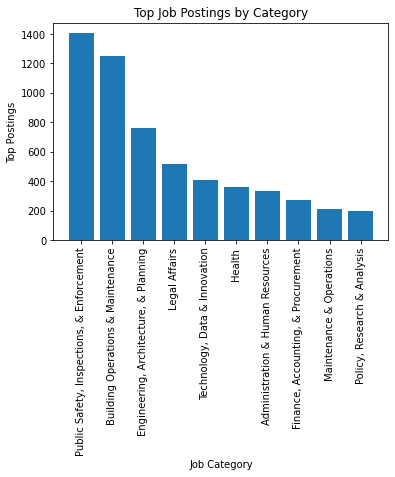

In [14]:
kpi1p=kpi1.toPandas()
plt.bar(kpi1p['Job Category'],kpi1p['top_postings'])
plt.xticks(rotation=90)
plt.xlabel("Job Category")
plt.ylabel("Top Postings")
plt.title("Top Job Postings by Category")


2.Whats the salary distribution per job category?

In [15]:
x=df.withColumn('average_sal',(F.col('Salary Range From')+F.col('Salary Range To'))/2)
kpi2=x.groupBy('Job Category').agg(F.avg('Salary Range From').alias('avg_sal_range_from'),F.avg('Salary Range To').alias('avg_sal_range_to'), F.avg('average_sal').alias('avg_sal')).orderBy(F.col('avg_sal').desc())
kpi2.orderBy(F.col('avg_sal').desc()).limit(10).show()

+--------------------+------------------+----------------+------------------+
|        Job Category|avg_sal_range_from|avg_sal_range_to|           avg_sal|
+--------------------+------------------+----------------+------------------+
|Administration & ...|          218587.0|        218587.0|          218587.0|
|Engineering, Arch...|          198518.0|        198518.0|          198518.0|
|Engineering, Arch...|          192292.5|        199792.5|          196042.5|
|Health Policy, Re...|          113504.0|        143885.0|          128694.5|
|Engineering, Arch...|           69940.0|        186555.0|          128247.5|
|Engineering, Arch...|           69940.0|        186555.0|          128247.5|
|Communications & ...|          115000.0|        135000.0|          125000.0|
|Administration & ...|           78574.0|        158000.0|          118287.0|
|Constituent Servi...|106666.66666666667|        127134.0|116900.33333333333|
|Constituent Servi...|           56990.0|        150371.0|      

Text(0.5, 1.0, 'Avg Salary per Job Category')

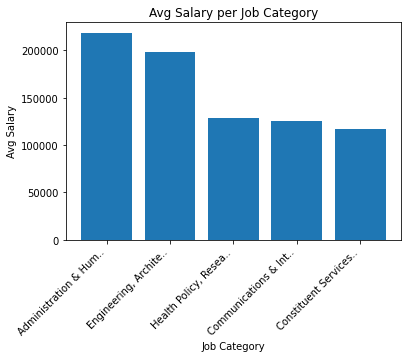

In [16]:
kpi2p=kpi2.orderBy(F.col('avg_sal').desc()).limit(10).toPandas()
plt.bar((kpi2p['Job Category'].str[0:20]+".."),kpi2p['avg_sal'])
plt.xticks(rotation=45,ha='right')
plt.xlabel("Job Category")
plt.ylabel("Avg Salary")
plt.title("Avg Salary per Job Category")

3.Is there any correlation between the higher degree and the salary?

In [17]:
degree_df = x.withColumn('Has_Higher_Degree',F.when(F.col("Minimum Qual Requirements").rlike("Bachelor|Master|PhD"), 1).otherwise(0))
corr=degree_df.stat.corr("Has_Higher_Degree", "average_sal")
print(corr)

0.0991540245867495


4.Whats the job posting having the highest salary per agency?

In [18]:
w=Window.partitionBy('agency').orderBy(F.col('average_sal').desc())
kpi4=x.withColumn('rnum',F.row_number().over(w)).filter(F.col('rnum')==1).select('agency','Job ID','Business Title','average_sal')
kpi4.show()

+--------------------+------+--------------------+-----------+
|              agency|Job ID|      Business Title|average_sal|
+--------------------+------+--------------------+-----------+
|LANDMARKS PRESERV...|425347|LANDMARKS PRESERV...|    60103.5|
|OFFICE OF COLLECT...|170989|COLLEGE AIDE - CL...|      9.555|
|     FIRE DEPARTMENT|420216|Senior Enterprise...|   120474.5|
|ADMIN FOR CHILDRE...|407253|Assistant Commiss...|   117474.5|
|MANHATTAN COMMUNI...|369120| Community Assistant|       19.0|
|      TAX COMMISSION|423630|       CITY ASSESSOR|    45088.5|
|HRA/DEPT OF SOCIA...|424997|EXECUTIVE DIRECTO...|   112527.5|
|TAXI & LIMOUSINE ...|413804|Executive Directo...|   140000.0|
|EQUAL EMPLOY PRAC...|420065|Director of Learn...|    67970.0|
|DEPARTMENT OF BUS...| 97899|EXECUTIVE DIRECTO...|   111377.0|
|DEPT OF DESIGN & ...|416442|Associate Commiss...|   151795.0|
|TEACHERS RETIREME...|420740|AGENCY ATTORNEY I...|    69078.5|
|DEPARTMENT OF COR...|423322|Assistant Commiss...|   13

5.Whats the job positings average salary per agency for the last 2 years?

In [19]:
#Since last two year's data is not there so doind calculats for latest two years present in data 
w=Window.orderBy(F.year('Posting Date').desc())
last_2_yr=x.withColumn('yr_posting_date',F.year('Posting Date')).withColumn('rnk',F.dense_rank().over(w)).filter(F.col('rnk')<=2).drop('rnk')
kpi5=last_2_yr.groupBy('agency').agg(F.avg('average_sal').alias('per_agency_avg_sal'))
kpi5.show()

+--------------------+------------------+
|              agency|per_agency_avg_sal|
+--------------------+------------------+
|NYC HOUSING AUTHO...| 85801.99691588785|
|ADMIN FOR CHILDRE...| 72548.61943382354|
|DEPT OF ENVIRONME...| 72208.92455369265|
|OFFICE OF THE COM...|        80960.3125|
|   POLICE DEPARTMENT| 67373.81489795918|
|NYC EMPLOYEES RET...| 98336.02777777778|
|DEPT OF HEALTH/ME...|  62758.3091198795|
|TAXI & LIMOUSINE ...| 61041.02986380597|
|DEPARTMENT OF CIT...|  72984.3111111111|
|DEPARTMENT OF BUS...|55392.794537999995|
|HOUSING PRESERVAT...| 80102.37790697675|
|DEPT OF YOUTH & C...| 66609.49549210526|
|DEPT OF DESIGN & ...| 87849.33802816902|
|DEPARTMENT OF PRO...| 74660.03826086957|
|      LAW DEPARTMENT|  82376.8701859155|
|FINANCIAL INFO SV...| 96021.12903225806|
|OFFICE OF MANAGEM...| 70050.45357142857|
|DEPARTMENT OF TRA...| 70484.36625954199|
|OFF OF PAYROLL AD...|60824.083333333336|
|CIVILIAN COMPLAIN...|47776.045352941175|
+--------------------+------------

6.What are the highest paid skills in the US market?

In [20]:
kpi6=x.groupBy('Preferred Skills').agg(F.avg(F.col('average_sal')).alias('skill_avg_sal')).orderBy(F.col('skill_avg_sal').desc())
kpi6.show(10)

+--------------------+-------------+
|    Preferred Skills|skill_avg_sal|
+--------------------+-------------+
|The Deputy Commis...|     218587.0|
|The Deputy Commis...|     209585.0|
|Extensive experie...|     198518.0|
|â€¢	10+ years of ...|     191913.0|
|Required Skills: ...|     182500.0|
|â€¢	A Masterâ€™s ...|     177374.5|
|Valid holder of t...|     169011.0|
|â€¢ Expert knowle...|     167500.0|
|â€¢ Clearly demon...|     167500.0|
|â€¢	At least 10 y...|     165000.0|
+--------------------+-------------+
only showing top 10 rows



Text(0.5, 1.0, 'Highest paid skills in the US market')

/usr/local/lib/python3.7/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 9 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.7/dist-packages/matplotlib/backends/backend_agg.py:183: RuntimeWarning: Glyph 9 missing from current font.
  font.set_text(s, 0, flags=flags)


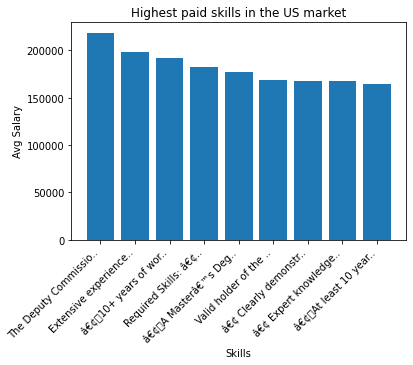

In [21]:
kpi6p=kpi6.limit(10).toPandas()
plt.bar((kpi6p['Preferred Skills'].str[0:20]+".."),kpi6p['skill_avg_sal'])
plt.xticks(rotation=45,ha='right')
plt.xlabel("Skills")
plt.ylabel("Avg Salary")
plt.title("Highest paid skills in the US market")

# Data Processing


In [22]:
#Function to remove duplicates(Both at Row level and composite key level)
def remove_duplicates(df, comp_keys=['Job ID','Agency','Posting Type']):
    #Removal of row level duplicates
    print("Before row level duplicacy removal - count : ", df.count())
    df=df.dropDuplicates()
    print("After row level duplicacy removal - count : ", df.count())
    
    #Removal of composite key level duplicates. Latest Entry will be preserved.
    w=Window.partitionBy(comp_keys).orderBy(F.col('Posting Date').desc(),F.col('Posting Updated').desc())
    df=df.withColumn('rnum', F.row_number().over(w)).filter(F.col('rnum')==1).drop('rnum')
    print("After row + comp key level duplicacy removal - count : ", df.count())
    return df
    
df=remove_duplicates(df)

   

Before row level duplicacy removal - count :  2946
After row level duplicacy removal - count :  2912
After row + comp key level duplicacy removal - count :  2911


In [23]:
#Function to handle nulls in composite key
def null_handling(df, comp_keys=['Job ID','Agency','Posting Type']):
    for i in comp_keys:
        n=df.filter(F.col(i).isNull()).count()  
        print("Nulls in ",i," : ", n)
        if(n>0):
            df=df.filter(F.col(i).isNotNull())
            print("Rows with Nulls in ",i," removed successfully.")
        return df
        
df=null_handling(df)


Nulls in  Job ID  :  1
Rows with Nulls in  Job ID  removed successfully.


In [24]:
#Function to remove left and right spaces in character columns if any
def trim_spaces(df):
    for i in char_cols:
        df=df.withColumn(i,F.trim(F.col(i))) 
    return df
        
df=trim_spaces(df)

        

In [25]:
#Function to rename column names into a standard format
def col_rename(df):
    df=df.withColumnRenamed('# Of Positions','No Of Positions')
    for field in df.schema.fields:
        df=df.withColumnRenamed(field.name, field.name.replace(' ','_').replace('/','_').lower())
    return df

df=col_rename(df)
df.printSchema()      

root
 |-- job_id: integer (nullable = true)
 |-- agency: string (nullable = true)
 |-- posting_type: string (nullable = true)
 |-- no_of_positions: integer (nullable = true)
 |-- business_title: string (nullable = true)
 |-- civil_service_title: string (nullable = true)
 |-- title_code_no: string (nullable = true)
 |-- level: string (nullable = true)
 |-- job_category: string (nullable = true)
 |-- full-time_part-time_indicator: string (nullable = true)
 |-- salary_range_from: double (nullable = true)
 |-- salary_range_to: double (nullable = true)
 |-- salary_frequency: string (nullable = true)
 |-- work_location: string (nullable = true)
 |-- division_work_unit: string (nullable = true)
 |-- job_description: string (nullable = true)
 |-- minimum_qual_requirements: string (nullable = true)
 |-- preferred_skills: string (nullable = true)
 |-- additional_information: string (nullable = true)
 |-- to_apply: string (nullable = true)
 |-- hours_shift: string (nullable = true)
 |-- work_loca

Feature Engineering

In [26]:
#1.
df=df.withColumn('avg_salary',(F.col('salary_range_from')+F.col('salary_range_to'))/2)

In [27]:
#2.
df=df.withColumn('posting_year',F.year(F.col('posting_date')))

In [28]:
#3.
df=df.withColumn('posting_month',F.month(F.col('posting_date')))

In [29]:
#4.
df=df.withColumn("new_york_res_mand", F.when(F.col('residency_requirement').contains('no' or 'not'), 'no').otherwise('yes'))

Feature Removal

In [30]:
def col_pruning(df):
    df=df.drop('recruitment_contact') #Since it has 100% nulls
    return df

df=col_pruning(df)
df.printSchema()

root
 |-- job_id: integer (nullable = true)
 |-- agency: string (nullable = true)
 |-- posting_type: string (nullable = true)
 |-- no_of_positions: integer (nullable = true)
 |-- business_title: string (nullable = true)
 |-- civil_service_title: string (nullable = true)
 |-- title_code_no: string (nullable = true)
 |-- level: string (nullable = true)
 |-- job_category: string (nullable = true)
 |-- full-time_part-time_indicator: string (nullable = true)
 |-- salary_range_from: double (nullable = true)
 |-- salary_range_to: double (nullable = true)
 |-- salary_frequency: string (nullable = true)
 |-- work_location: string (nullable = true)
 |-- division_work_unit: string (nullable = true)
 |-- job_description: string (nullable = true)
 |-- minimum_qual_requirements: string (nullable = true)
 |-- preferred_skills: string (nullable = true)
 |-- additional_information: string (nullable = true)
 |-- to_apply: string (nullable = true)
 |-- hours_shift: string (nullable = true)
 |-- work_loca

Store your processed data into a target file

In [31]:
df.coalesce(1).write.mode("overwrite").csv("/dataset/nyc-jobs-output", header=True)


#Test Cases

In [32]:
assert df.count() > 0, "Dataset is empty!"
assert df.filter(F.col("salary_range_from") < 0).count() == 0, "Negative salary found!"
assert df.filter(F.col("salary_range_to") < 0).count() == 0, "Negative salary found!"
assert df.count() == df.distinct().count(), "Duplicates are there!"
assert "avg_salary" in df.columns, "Avg Sal Feature not created!"
assert "posting_year" in df.columns, "Posting Year Feature not created!"
assert "posting_month" in df.columns, "Posting Month Feature not created!"
assert "new_york_res_mand" in df.columns, "NewYork Residence Mandate Feature not created!"
assert "recruitment_contact" not in df.columns, "Feature removal not happened!"
